## Crop Recommendation System for Smart Agriculture

### Objective
To develop a machine learning-based crop recommendation system that predicts the most suitable crop for cultivation based on soil nutrient levels (N, P, K) and environmental conditions (temperature, humidity, pH, rainfall), enabling farmers to make data-driven and efficient agricultural decisions.

### Workflow
Data Exploration → Data Preprocessing → Model Training & Comparison → Hyperparameter Tuning → Model Evaluation → Deployment (Prediction System)

Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

Load & Clean Data

In [2]:
df = pd.read_csv('Crop_recommendation.csv')

print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

if df.isnull().sum().sum() > 0:
    df = df.dropna()

df.head()

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows: 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Domain-Based Cleaning

In [3]:
rules = {
    'N': (0, 150),
    'P': (0, 150),
    'K': (0, 200),
    'temperature': (0, 50),
    'humidity': (0, 100),
    'ph': (0, 14),
    'rainfall': (0, float('inf'))
}

mask = pd.Series(True, index=df.index)

for col, (low, high) in rules.items():
    mask &= df[col].between(low, high)

df_clean = df[mask].copy()

print("Original size:", df.shape)
print("Cleaned size:", df_clean.shape)

Original size: (8800, 8)
Cleaned size: (8498, 8)


Split Features & Target

In [4]:
X = df_clean.drop('label', axis=1)
y = df_clean['label']

EDA

In [5]:
print(X.describe())
print(y.value_counts())

                 N            P            K  temperature     humidity  \
count  8498.000000  8498.000000  8498.000000  8498.000000  8498.000000   
mean     56.033302    49.655095    36.429277    26.824401    70.811596   
std      37.282548    24.788521    29.125333     5.146020    22.853500   
min       0.000000     4.000000     5.000000     9.535586    14.258040   
25%      26.000000    30.000000    20.000000    23.892719    57.232652   
50%      43.000000    50.000000    27.000000    26.916248    78.125867   
75%      90.000000    65.000000    46.000000    29.737031    89.340725   
max     149.000000   150.000000   200.000000    46.732778    99.999879   

                ph     rainfall  
count  8498.000000  8498.000000  
mean      6.626633   100.671549  
std       0.886474    56.168630  
min       3.504752    20.211267  
25%       6.097294    58.995363  
50%       6.591888    90.891731  
75%       7.117686   122.456420  
max      10.233143   298.560117  
label
rice           400
ma

Boxplots

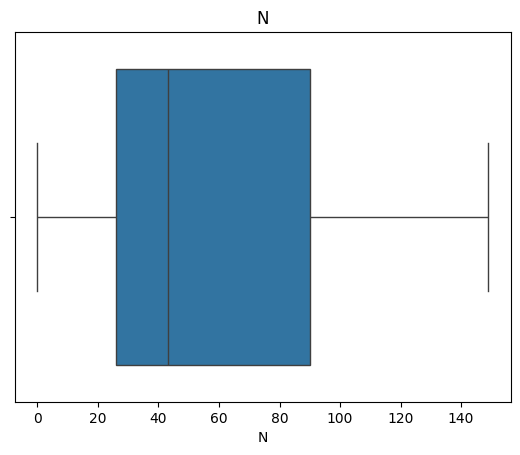

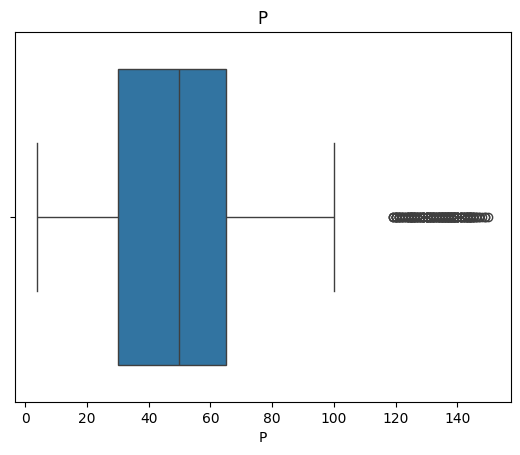

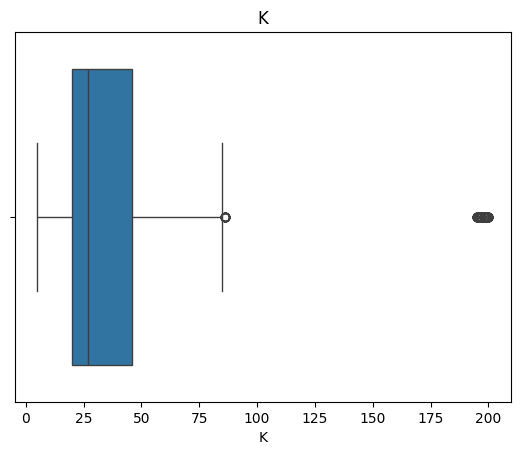

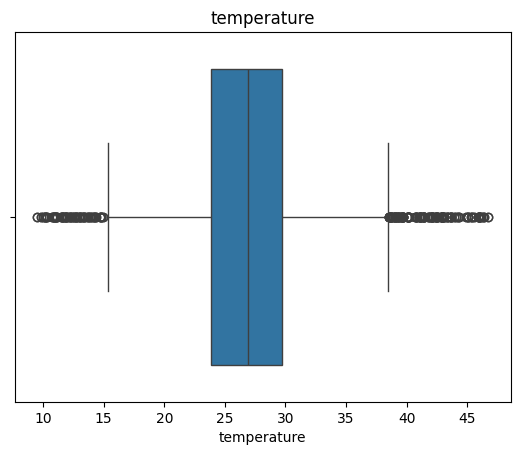

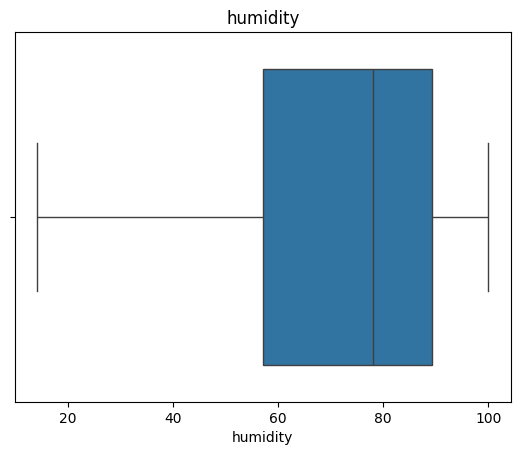

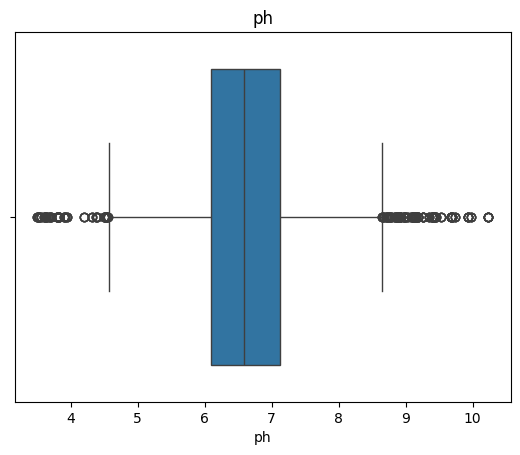

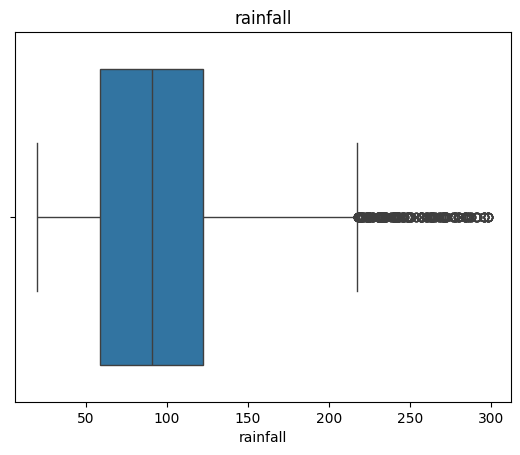

In [6]:
for col in X.columns:
    plt.figure()
    sns.boxplot(x=X[col])
    plt.title(col)
    plt.show()

Histograms

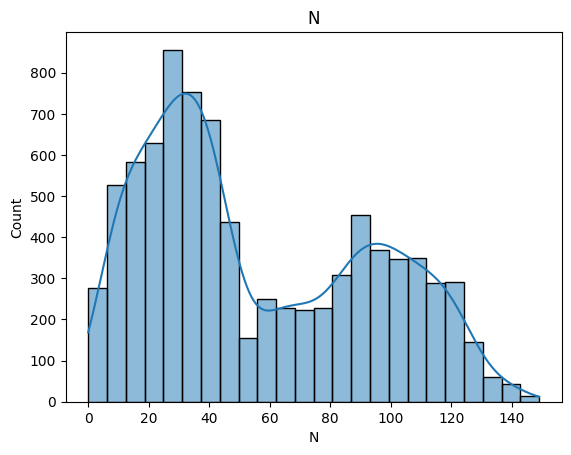

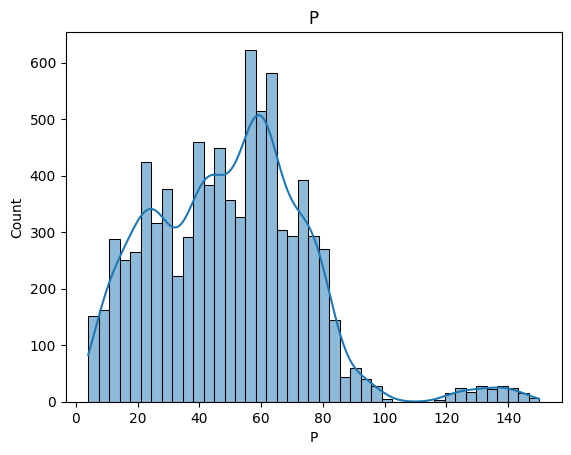

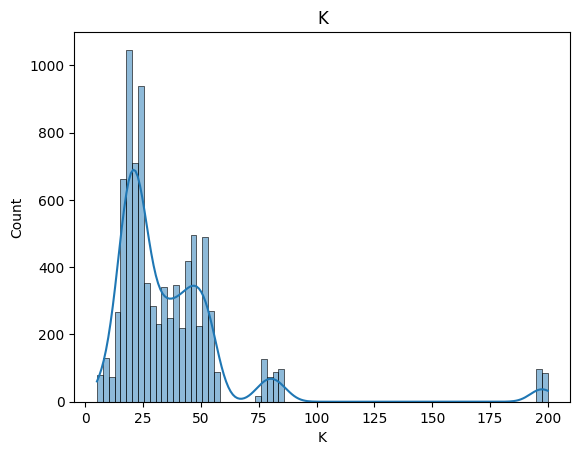

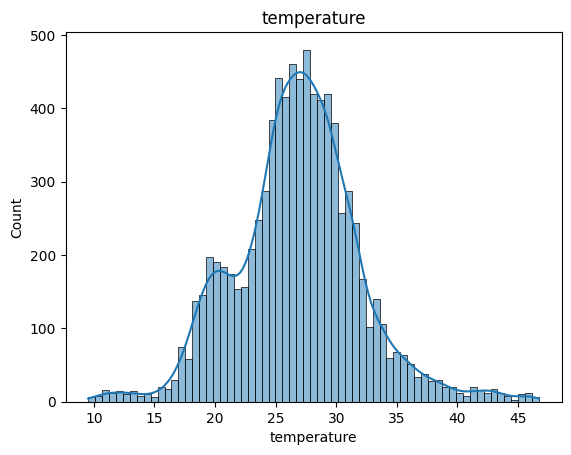

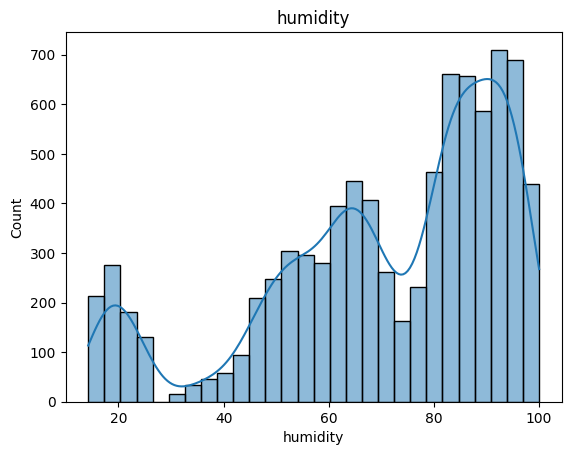

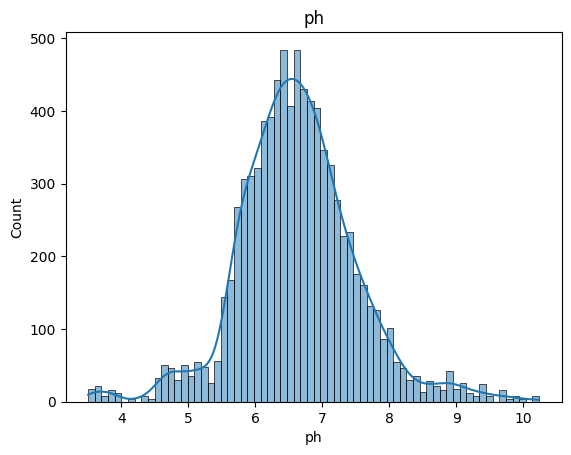

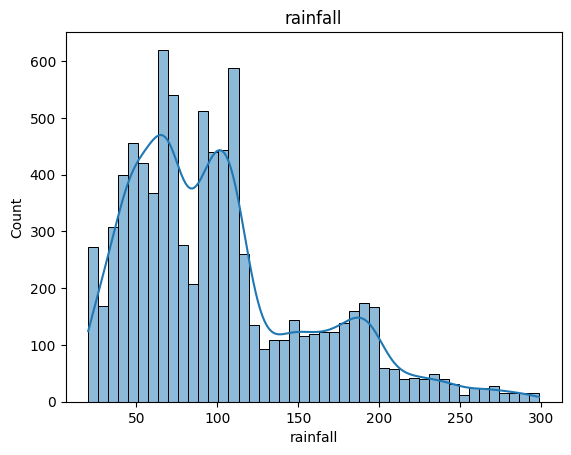

In [7]:
for col in X.columns:
    sns.histplot(X[col], kde=True)
    plt.title(col)
    plt.show()

Correlation Heatmap

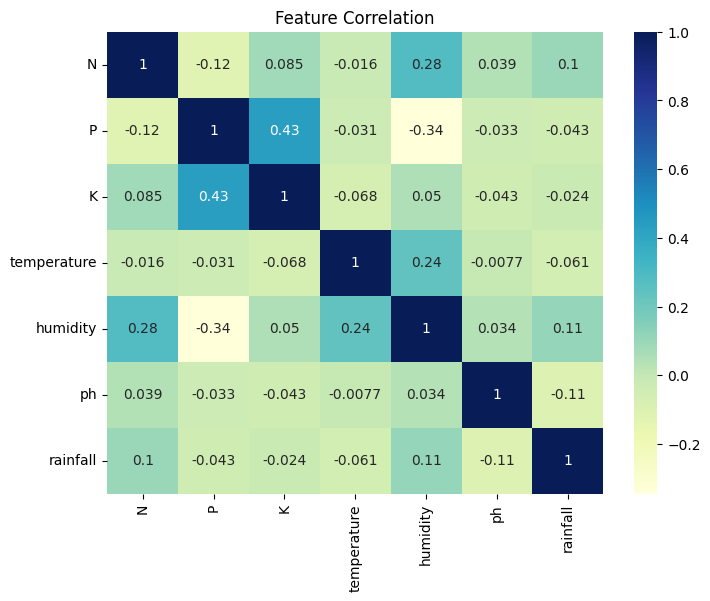

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot = True, cmap = "YlGnBu")
plt.title('Feature Correlation')
plt.show()

Label Encoding

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

{'banana': np.int64(0), 'blackgram': np.int64(1), 'chickpea': np.int64(2), 'coconut': np.int64(3), 'coffee': np.int64(4), 'cotton': np.int64(5), 'grapes': np.int64(6), 'groundnuts': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

Model Comparison

In [11]:
models = {
    "RandomForest": Pipeline([
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "LogisticRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=200))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ])
}

print("\nModel Comparison:\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")


Model Comparison:

RandomForest: 0.9187 ± 0.0041
LogisticRegression: 0.9245 ± 0.0037
SVM: 0.9370 ± 0.0014


Hyperparameter Tuning

In [12]:
param_grid = param_grid = {
 'n_estimators': [100, 200],
 'max_depth': [None, 10, 20],
 'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


Final Model 

In [13]:
model = Pipeline([
    ('model', RandomForestClassifier(
        **grid.best_params_,
        random_state=42,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=5,
                                        random_state=42))])

Evaluation

In [14]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9188235294117647

Classification Report:

              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        80
   blackgram       1.00      1.00      1.00        80
    chickpea       1.00      1.00      1.00        80
     coconut       1.00      1.00      1.00        63
      coffee       1.00      1.00      1.00        80
      cotton       0.96      1.00      0.98        80
      grapes       1.00      1.00      1.00        37
  groundnuts       0.22      0.24      0.23        80
        jute       0.92      1.00      0.96        80
 kidneybeans       1.00      1.00      1.00        80
      lentil       1.00      1.00      1.00        80
       maize       1.00      0.96      0.98        80
       mango       1.00      1.00      1.00        80
   mothbeans       0.18      0.16      0.17        80
    mungbean       1.00      1.00      1.00        80
   muskmelon       1.00      1.00      1.00        80
      orange       1.00    

Confusion Matrix

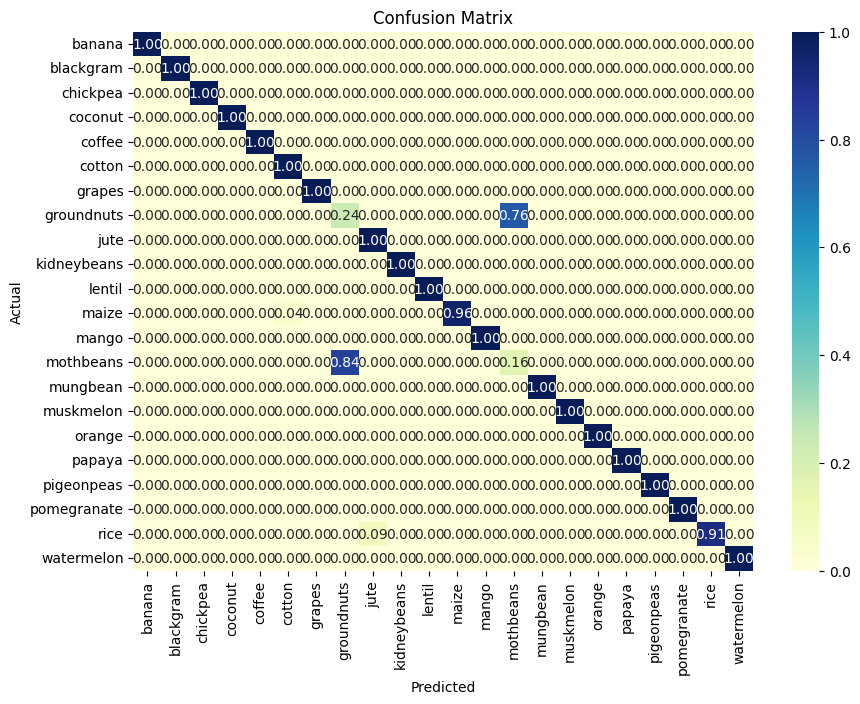

In [15]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10,7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.show()

Feature Importance

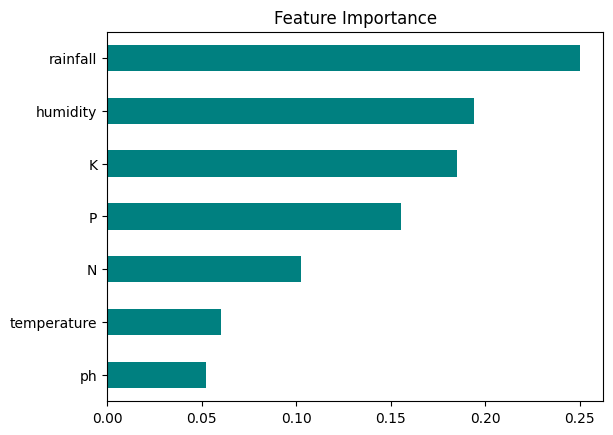

In [16]:
feat = pd.Series(
    model.named_steps["model"].feature_importances_,
    index=X.columns
)

feat.sort_values().plot(kind="barh", color="teal")
plt.title("Feature Importance")
plt.show()

Input Validation

In [17]:
def validate_input(data):
    if len(data) != 7:
        raise ValueError("Need 7 features")

    N, P, K, temp, humidity, ph, rainfall = data

    if not (0 <= N <= 150): raise ValueError("N out of range")
    if not (0 <= P <= 150): raise ValueError("P out of range")
    if not (0 <= K <= 200): raise ValueError("K out of range")
    if not (0 <= temp <= 50): raise ValueError("Temp out of range")
    if not (0 <= humidity <= 100): raise ValueError("Humidity out of range")
    if not (0 <= ph <= 14): raise ValueError("pH out of range")
    if rainfall < 0: raise ValueError("Rainfall invalid")

Prediction Function

In [18]:
feature_order = ['N','P','K','temperature','humidity','ph','rainfall']

def recommend(input_data, threshold=0.6):
    validate_input(input_data)

    df_input = pd.DataFrame([input_data], columns=feature_order)

    probs = model.predict_proba(df_input)[0]

    top_idx = np.argsort(probs)[::-1][:3]

    top_k = [
        (le.inverse_transform([i])[0], probs[i])
        for i in top_idx
    ]

    best_crop, best_prob = top_k[0]

    return {
        "best_crop": best_crop,
        "confidence": round(best_prob, 3),
        "top_3": [(c, round(p, 2)) for c, p in top_k],
        "status": "High confidence" if best_prob >= threshold else "Low confidence"
    }

Test Samples

In [19]:
samples = [
    [40, 50, 50, 25.5, 70, 6.8, 150],
    [20, 60, 30, 28, 80, 5.8, 100],
    [120, 40, 20, 22, 60, 7, 300]
]

for i, s in enumerate(samples, 1):
    print(f"\nSample {i}")
    print(recommend(s))


Sample 1
{'best_crop': 'papaya', 'confidence': np.float64(0.269), 'top_3': [('papaya', np.float64(0.27)), ('pigeonpeas', np.float64(0.24)), ('jute', np.float64(0.22))], 'status': 'Low confidence'}

Sample 2
{'best_crop': 'papaya', 'confidence': np.float64(0.168), 'top_3': [('papaya', np.float64(0.17)), ('mungbean', np.float64(0.17)), ('mango', np.float64(0.12))], 'status': 'Low confidence'}

Sample 3
{'best_crop': 'coffee', 'confidence': np.float64(0.553), 'top_3': [('coffee', np.float64(0.55)), ('maize', np.float64(0.22)), ('rice', np.float64(0.1))], 'status': 'Low confidence'}


Save Model

In [20]:
joblib.dump({"model": model, "encoder": le}, "crop_system.pkl")

['crop_system.pkl']